# 90 — Tiện ích: sinh 14 hình cho báo cáo tuần 2

Notebook này **tái tạo toàn bộ hình** mà `docs/bao_cao_tuan2_HOAN_CHINH.md` đang dùng.

## Vì sao cần notebook này

Trước đây 14 hình dưới đây được sinh bởi script nằm ngoài repo → **không sửa được, không tái tạo
được**. Notebook này đưa chúng vào project để hình luôn dựng lại được từ dữ liệu gốc.

| Nhóm | Hình | Nội dung |
|---|---|---|
| **O** — Tổng quan | `O1`, `O2` | Mức giải thích được · phân rã phương sai |
| **B** — Giá cơ bản | `B1_B2`, `B3_B4`, `B5`, `B6` | Quãng đường/thời lượng · giờ/thời tiết · sàn nhiễu · importance |
| **M** — Hệ số nhân | `M1_M2`, `M3_M4`, `M5` | Cung–cầu · giờ/thời tiết · hằng số thị trường |
| **F** — Giá cuối | `F1`, `F2`, `F3` | Biên độ · Boston vs HCM · phân bố cùng điều kiện |
| **T** — Khung giờ | `T1`, `T2` | Thời lượng/tốc độ theo giờ · 6 khung giờ |

## Nguồn dữ liệu

Đọc **trực tiếp từ dữ liệu gốc** (`data/synthetic_data/.../hexes/*.csv.gz`) qua `_common.py`,
lấy mẫu **20%**. Không phụ thuộc `hcm_train_ready.parquet` hay model đã train.

⚠️ `F2` dùng số liệu Boston đã tính sẵn ở tuần 1 (hằng số trong code, không đọc lại bộ Boston).

**Thời gian chạy:** ~3–5 phút (phần lâu nhất là nạp dữ liệu và `B6` train model nhỏ).

In [1]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")
from _common import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
%matplotlib inline

OUT = Path("../docs/hinh_anh"); OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"savefig.dpi": 150, "savefig.bbox": "tight"})

setup()
df = load(frac=0.2)
df["base_price"] = df[PRICE] / df[SURGE].clip(lower=0.1)
df["co_mua"] = ((df.weather_is_rain == 1) | (df.weather_is_drizzle == 1) |
                (df.weather_is_thunderstorm == 1)).astype(int)

# Cac tap con dung lai nhieu lan
dv0 = df.service_name.iloc[0]
band = df[(df.pickup_location_name == "Crescent Mall") &
          (df.dropoff_location_name == "SC Vivo City") &
          (df.service_name == dv0) &
          (df.quote_distance.between(5.4, 5.6))].copy()
band4_6 = df[(df.quote_distance >= 4) & (df.quote_distance <= 6)].copy()

print(f"\nband (cung tuyen+xe+km) : {len(band):,} chuyen")
print(f"band4_6 (dai 4-6km)     : {len(band4_6):,} chuyen")
print(f"Luu hinh vao            : {OUT.resolve()}")

Nap 1,379,423 dong (mau 20%) | gia median 114k VND | surge 81.7%



band (cung tuyen+xe+km) : 15,215 chuyen
band4_6 (dai 4-6km)     : 526,450 chuyen
Luu hinh vao            : C:\Users\Admin\OneDrive\Máy tính\Pricing_Reseach_Vin AI\TP_HCM_data\docs\hinh_anh


## Nhóm O — Tổng quan

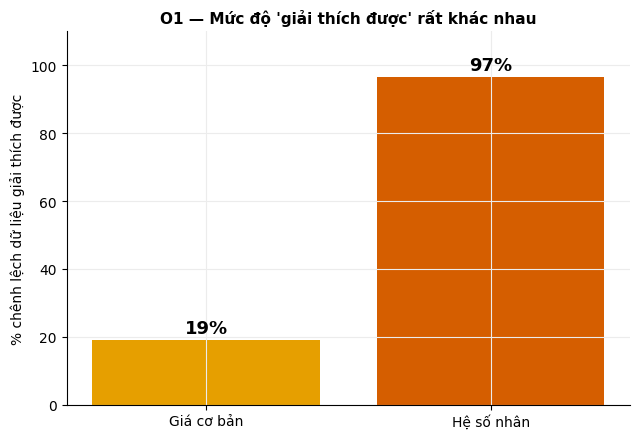

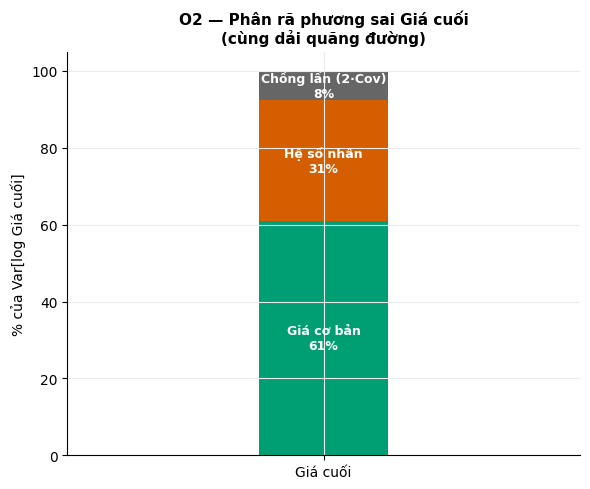

Phan ra: gia co ban 61% | he so nhan 31% | chong lan 8%


In [2]:
# ===== O1: muc do giai thich duoc =====
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(["Giá cơ bản", "Hệ số nhân"], [19, 96.6], color=[ORANGE, RED])
for b, v in zip(bars, [19, 96.6]):
    ax.text(b.get_x()+b.get_width()/2, v+2, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=13)
ax.set_ylabel("% chênh lệch dữ liệu giải thích được"); ax.set_ylim(0, 110)
ax.set_title("O1 — Mức độ 'giải thích được' rất khác nhau", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(OUT / "O1_r2_giaithich.png"); plt.show()

# ===== O2: phan ra phuong sai =====
lp, lb, lm = np.log(band4_6[PRICE]), np.log(band4_6.base_price), np.log(band4_6[SURGE])
v_p = lp.var()
vals = [lb.var()/v_p*100, lm.var()/v_p*100, 2*np.cov(lb, lm)[0, 1]/v_p*100]
fig, ax = plt.subplots(figsize=(6, 5))
bottom = 0
for v, l, c in zip(vals, ["Giá cơ bản", "Hệ số nhân", "Chồng lấn (2·Cov)"], [GREEN, RED, MUT]):
    ax.bar(["Giá cuối"], [v], bottom=bottom, label=l, color=c, width=0.5)
    ax.text(0, bottom+v/2, f"{l}\n{v:.0f}%", ha="center", va="center",
            fontsize=9, color="white", fontweight="bold")
    bottom += v
ax.set_ylabel("% của Var[log Giá cuối]"); ax.set_xlim(-1, 1)
ax.set_title("O2 — Phân rã phương sai Giá cuối\n(cùng dải quãng đường)", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(OUT / "O2_phanra_phuongsai.png"); plt.show()
print(f"Phan ra: gia co ban {vals[0]:.0f}% | he so nhan {vals[1]:.0f}% | chong lan {vals[2]:.0f}%")

## Nhóm B — Giá cơ bản

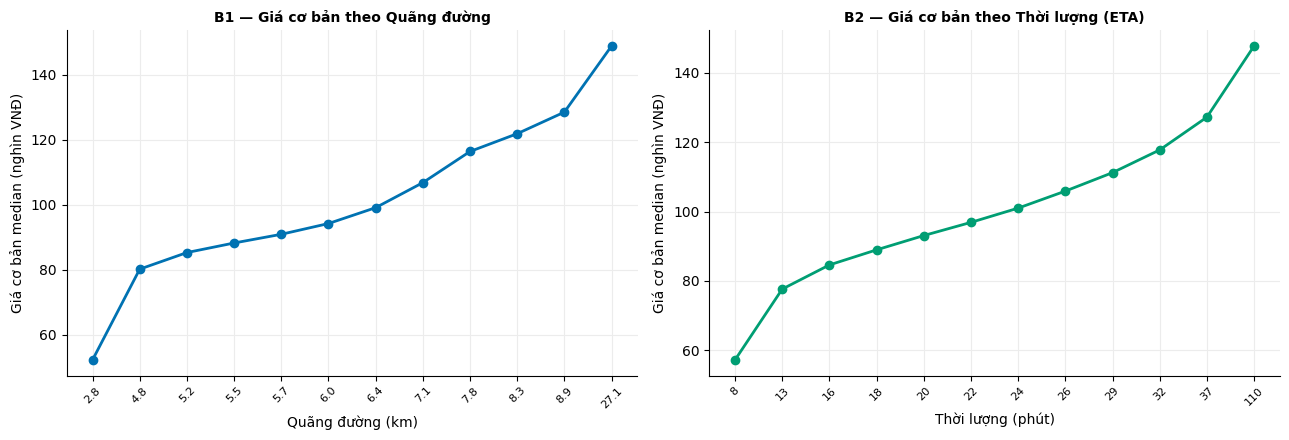

In [3]:
# ===== B1/B2: quang duong & thoi luong =====
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
g1 = df.groupby(pd.qcut(df.quote_distance, 12, duplicates="drop"), observed=True).base_price.median()
ax[0].plot(range(len(g1)), g1.values/1000, marker="o", lw=2, color=BLUE)
ax[0].set_xticks(range(len(g1)))
ax[0].set_xticklabels([f"{iv.mid:.1f}" for iv in g1.index], rotation=45, fontsize=8)
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Giá cơ bản median (nghìn VNĐ)")
ax[0].set_title("B1 — Giá cơ bản theo Quãng đường", fontweight="bold", fontsize=10)

g2 = df.groupby(pd.qcut(df.quote_duration/60, 12, duplicates="drop"), observed=True).base_price.median()
ax[1].plot(range(len(g2)), g2.values/1000, marker="o", lw=2, color=GREEN)
ax[1].set_xticks(range(len(g2)))
ax[1].set_xticklabels([f"{iv.mid:.0f}" for iv in g2.index], rotation=45, fontsize=8)
ax[1].set_xlabel("Thời lượng (phút)"); ax[1].set_ylabel("Giá cơ bản median (nghìn VNĐ)")
ax[1].set_title("B2 — Giá cơ bản theo Thời lượng (ETA)", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "B1_B2_distance_duration_vs_baseprice.png"); plt.show()

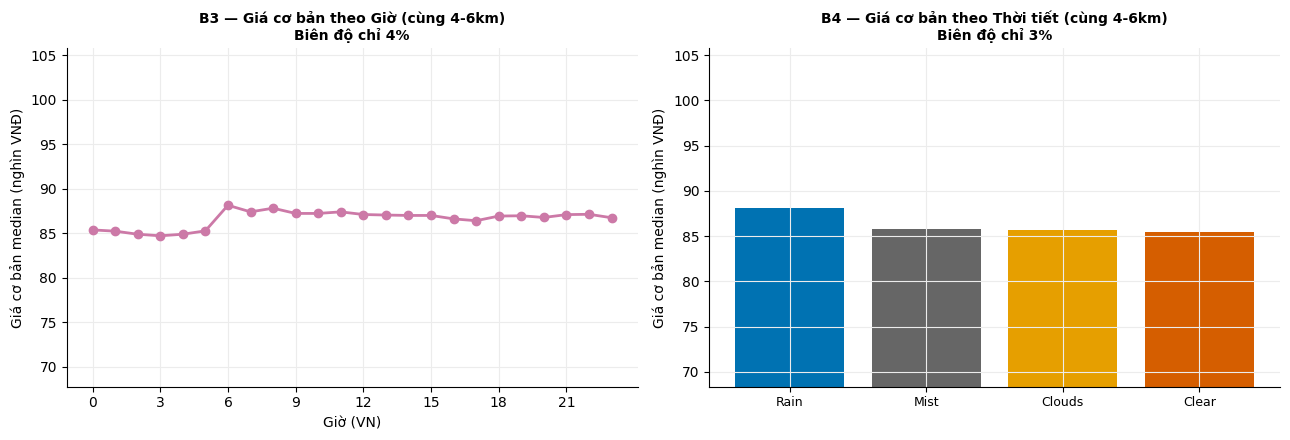

Bien do theo gio: 4.0% | theo thoi tiet: 3.2%


In [4]:
# ===== B3/B4: gio & thoi tiet (cung 4-6km) =====
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
g3 = band4_6.groupby("gio_vn").base_price.median()
ax[0].plot(g3.index, g3.values/1000, marker="o", lw=2, color=PURPLE)
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Giá cơ bản median (nghìn VNĐ)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].set_ylim(g3.min()/1000*0.8, g3.max()/1000*1.2)
bd3 = (g3.max()/g3.min()-1)*100
ax[0].set_title(f"B3 — Giá cơ bản theo Giờ (cùng 4-6km)\nBiên độ chỉ {bd3:.0f}%",
                fontweight="bold", fontsize=10)

g4 = band4_6.groupby("weather_main").base_price.median().sort_values(ascending=False)
ax[1].bar(range(len(g4)), g4.values/1000, color=[BLUE, MUT, ORANGE, RED][:len(g4)])
ax[1].set_xticks(range(len(g4))); ax[1].set_xticklabels(g4.index, fontsize=9)
ax[1].set_ylabel("Giá cơ bản median (nghìn VNĐ)")
ax[1].set_ylim(g4.min()/1000*0.8, g4.max()/1000*1.2)
bd4 = (g4.max()/g4.min()-1)*100
ax[1].set_title(f"B4 — Giá cơ bản theo Thời tiết (cùng 4-6km)\nBiên độ chỉ {bd4:.0f}%",
                fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "B3_B4_hour_weather_vs_baseprice.png"); plt.show()
print(f"Bien do theo gio: {bd3:.1f}% | theo thoi tiet: {bd4:.1f}%")

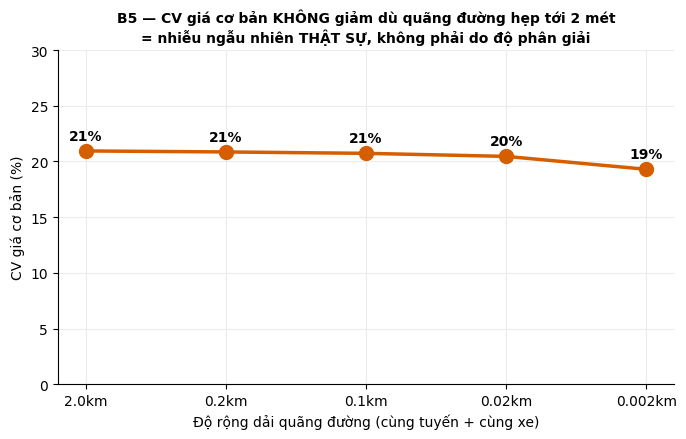

CV theo do rong dai: ['20.9%', '20.9%', '20.7%', '20.5%', '19.3%']


In [5]:
# ===== B5: CV KHONG giam du thu hep quang duong toi 2 met =====
do_rong = [2.0, 0.2, 0.1, 0.02, 0.002]
cvs = []
for lo, hi in [(4.0, 6.0), (5.4, 5.6), (5.45, 5.55), (5.49, 5.51), (5.499, 5.501)]:
    bb = df[(df.pickup_location_name == "Crescent Mall") &
            (df.dropoff_location_name == "SC Vivo City") &
            (df.service_name == dv0) & (df.quote_distance.between(lo, hi))]
    cvs.append(bb.base_price.std()/bb.base_price.mean()*100 if len(bb) >= 30 else np.nan)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(do_rong)), cvs, marker="o", lw=2.5, color=RED, markersize=10)
ax.set_xticks(range(len(do_rong))); ax.set_xticklabels([f"{d}km" for d in do_rong])
ax.set_xlabel("Độ rộng dải quãng đường (cùng tuyến + cùng xe)")
ax.set_ylabel("CV giá cơ bản (%)"); ax.set_ylim(0, 30)
for i, v in enumerate(cvs):
    if not np.isnan(v):
        ax.text(i, v+1, f"{v:.0f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_title("B5 — CV giá cơ bản KHÔNG giảm dù quãng đường hẹp tới 2 mét\n"
             "= nhiễu ngẫu nhiên THẬT SỰ, không phải do độ phân giải",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "B5_cv_khong_giam.png"); plt.show()
print("CV theo do rong dai:", [f"{v:.1f}%" for v in cvs])

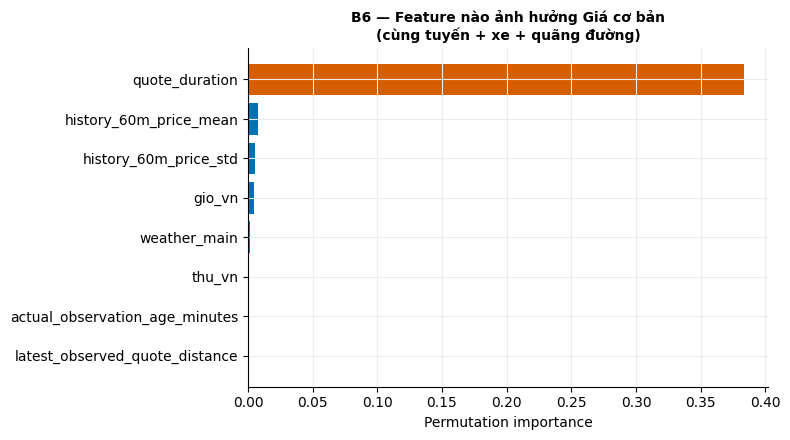

,Feature,Importance
0,quote_duration,0.38324
4,history_60m_price_mean,0.00797
5,history_60m_price_std,0.00514
1,gio_vn,0.00457
3,weather_main,0.00178
2,thu_vn,0.00108
6,actual_observation_age_minutes,0.00085
7,latest_observed_quote_distance,0.00037


In [6]:
# ===== B6: permutation importance (cung tuyen+xe+km) =====
FEATS_B = ["quote_duration", "gio_vn", "thu_vn", "weather_main",
           "history_60m_price_mean", "history_60m_price_std",
           "actual_observation_age_minutes", "latest_observed_quote_distance"]
X = band[FEATS_B].copy(); X["weather_main"] = X["weather_main"].astype("category")
Xtr, Xte, ytr, yte = train_test_split(X, band.base_price.values, test_size=0.25, random_state=42)
m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                  categorical_features=["weather_main"],
                                  random_state=42).fit(Xtr, np.log(ytr))
pi = permutation_importance(m, Xte, np.log(yte), n_repeats=10, random_state=42, n_jobs=1)
imp = pd.DataFrame({"Feature": FEATS_B, "Importance": pi.importances_mean}).sort_values("Importance")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp.Feature, imp.Importance,
        color=[RED if v == imp.Importance.max() else BLUE for v in imp.Importance])
ax.set_xlabel("Permutation importance")
ax.set_title("B6 — Feature nào ảnh hưởng Giá cơ bản\n(cùng tuyến + xe + quãng đường)",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "B6_permutation_baseprice.png"); plt.show()
display(imp.sort_values("Importance", ascending=False).round(5))

## Nhóm M — Hệ số nhân

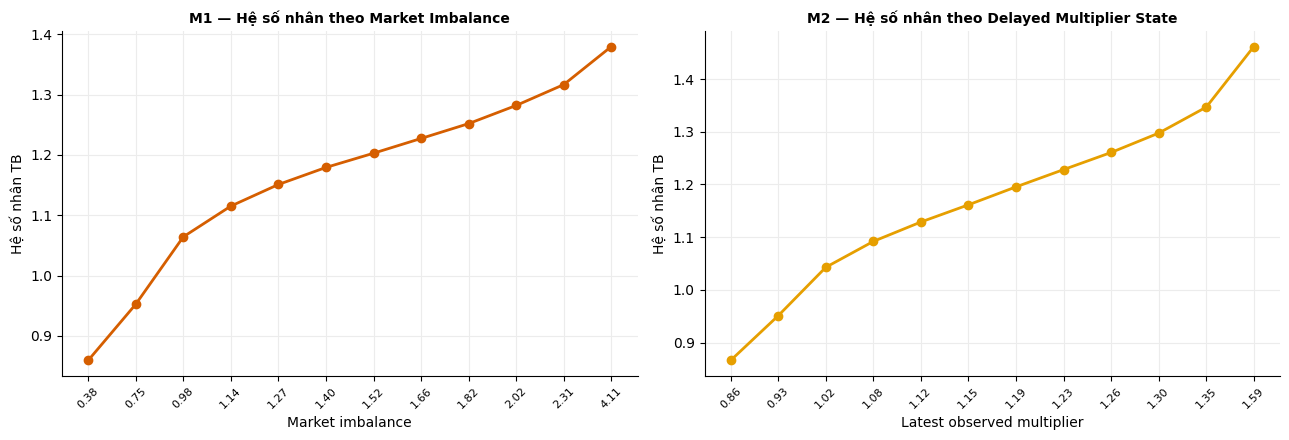

In [7]:
# ===== M1/M2: cung-cau & delayed multiplier =====
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
gm1 = df.groupby(pd.qcut(df.pricing_market_imbalance_5m_lag, 12, duplicates="drop"),
                 observed=True)[SURGE].mean()
ax[0].plot(range(len(gm1)), gm1.values, marker="o", lw=2, color=RED)
ax[0].set_xticks(range(len(gm1)))
ax[0].set_xticklabels([f"{iv.mid:.2f}" for iv in gm1.index], rotation=45, fontsize=8)
ax[0].set_xlabel("Market imbalance"); ax[0].set_ylabel("Hệ số nhân TB")
ax[0].set_title("M1 — Hệ số nhân theo Market Imbalance", fontweight="bold", fontsize=10)

gm2 = df.groupby(pd.qcut(df.latest_observed_multiplier, 12, duplicates="drop"),
                 observed=True)[SURGE].mean()
ax[1].plot(range(len(gm2)), gm2.values, marker="o", lw=2, color=ORANGE)
ax[1].set_xticks(range(len(gm2)))
ax[1].set_xticklabels([f"{iv.mid:.2f}" for iv in gm2.index], rotation=45, fontsize=8)
ax[1].set_xlabel("Latest observed multiplier"); ax[1].set_ylabel("Hệ số nhân TB")
ax[1].set_title("M2 — Hệ số nhân theo Delayed Multiplier State", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "M1_M2_imbalance_lastmult.png"); plt.show()

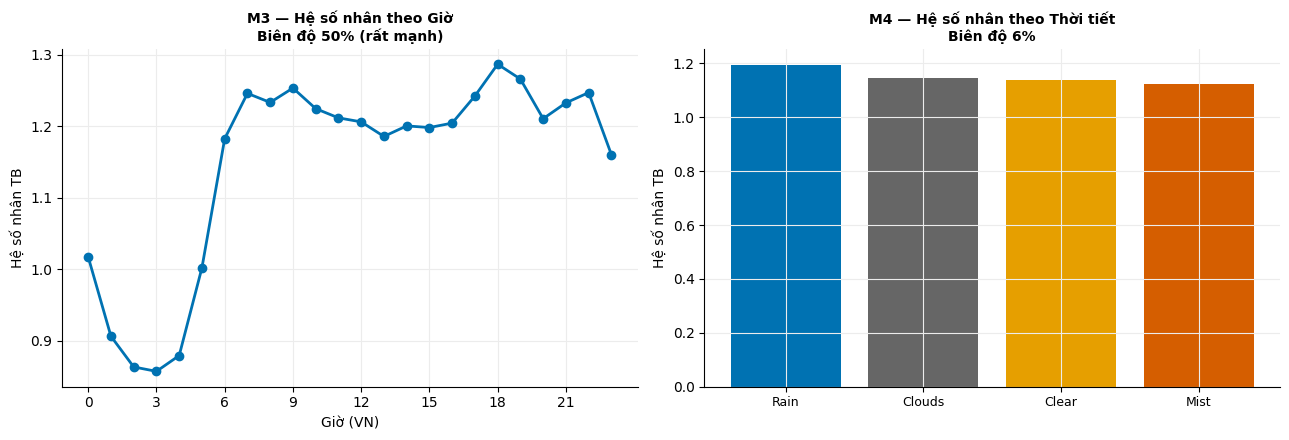

Bien do he so nhan — theo gio: 50% | theo thoi tiet: 6%


In [8]:
# ===== M3/M4: gio & thoi tiet =====
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
gm3 = df.groupby("gio_vn")[SURGE].mean()
ax[0].plot(gm3.index, gm3.values, marker="o", lw=2, color=BLUE)
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Hệ số nhân TB"); ax[0].set_xticks(range(0, 24, 3))
bd_m3 = (gm3.max()/gm3.min()-1)*100
ax[0].set_title(f"M3 — Hệ số nhân theo Giờ\nBiên độ {bd_m3:.0f}% (rất mạnh)",
                fontweight="bold", fontsize=10)

gm4 = df.groupby("weather_main")[SURGE].mean().sort_values(ascending=False)
ax[1].bar(range(len(gm4)), gm4.values, color=[BLUE, MUT, ORANGE, RED][:len(gm4)])
ax[1].set_xticks(range(len(gm4))); ax[1].set_xticklabels(gm4.index, fontsize=9)
ax[1].set_ylabel("Hệ số nhân TB")
bd_m4 = (gm4.max()/gm4.min()-1)*100
ax[1].set_title(f"M4 — Hệ số nhân theo Thời tiết\nBiên độ {bd_m4:.0f}%",
                fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "M3_M4_hour_weather_vs_multiplier.png"); plt.show()
print(f"Bien do he so nhan — theo gio: {bd_m3:.0f}% | theo thoi tiet: {bd_m4:.0f}%")

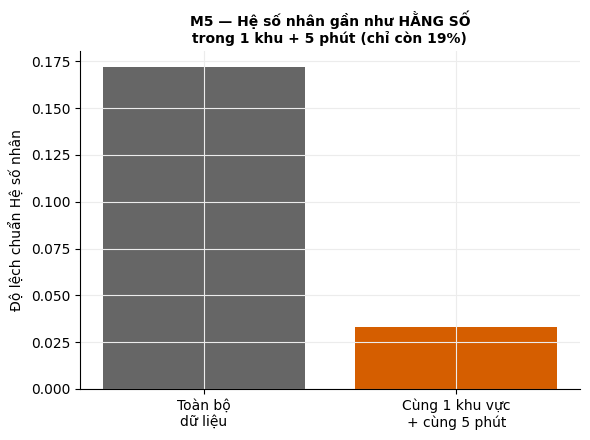

Std toan bo: 0.1718 | trong nhom: 0.0329 (19.2%)


In [9]:
# ===== M5: he so nhan gan nhu HANG SO trong 1 khu + 5 phut =====
df["bucket_5m"] = pd.to_datetime(df.current_timestamp_utc).dt.floor("5min")
grp = df.groupby(["pickup_hex_id_7", "bucket_5m"])[SURGE].agg(["std", "count"])
grp = grp[grp["count"] >= 5]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Toàn bộ\ndữ liệu", "Cùng 1 khu vực\n+ cùng 5 phút"],
       [df[SURGE].std(), grp["std"].mean()], color=[MUT, RED])
ax.set_ylabel("Độ lệch chuẩn Hệ số nhân")
ty_le = grp["std"].mean()/df[SURGE].std()*100
ax.set_title(f"M5 — Hệ số nhân gần như HẰNG SỐ\ntrong 1 khu + 5 phút (chỉ còn {ty_le:.0f}%)",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "M5_hang_so_thi_truong.png"); plt.show()
print(f"Std toan bo: {df[SURGE].std():.4f} | trong nhom: {grp['std'].mean():.4f} ({ty_le:.1f}%)")

## Nhóm F — Giá cuối

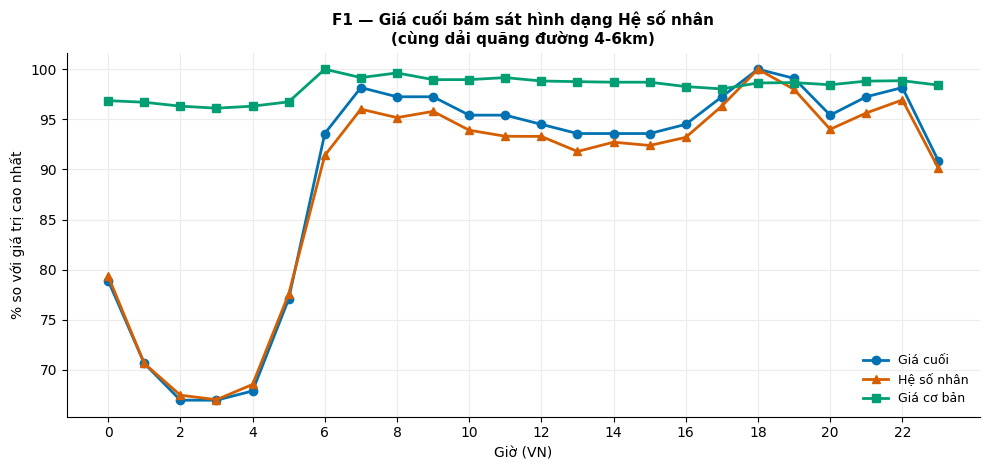

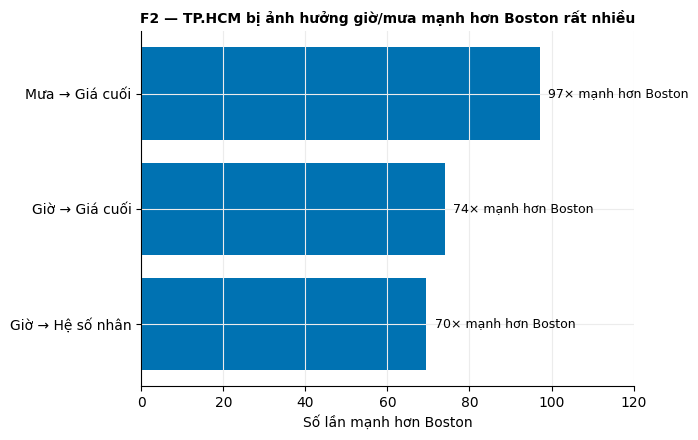

In [10]:
# ===== F1: bien do theo gio, chuan hoa % =====
gf1 = band4_6.groupby("gio_vn")[PRICE].median()
gf2 = band4_6.groupby("gio_vn")[SURGE].mean()
gf3 = band4_6.groupby("gio_vn").base_price.median()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(gf1.index, gf1/gf1.max()*100, marker="o", lw=2, color=BLUE, label="Giá cuối")
ax.plot(gf2.index, gf2/gf2.max()*100, marker="^", lw=2, color=RED, label="Hệ số nhân")
ax.plot(gf3.index, gf3/gf3.max()*100, marker="s", lw=2, color=GREEN, label="Giá cơ bản")
ax.set_xlabel("Giờ (VN)"); ax.set_ylabel("% so với giá trị cao nhất"); ax.set_xticks(range(0, 24, 2))
ax.set_title("F1 — Giá cuối bám sát hình dạng Hệ số nhân\n(cùng dải quãng đường 4-6km)",
             fontweight="bold", fontsize=11)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(OUT / "F1_amplitude_gia_cuoi.png"); plt.show()

# ===== F2: Boston vs HCM (so lieu tuan 1) =====
fig, ax = plt.subplots(figsize=(7, 4.5))
cats = ["Giờ → Hệ số nhân", "Giờ → Giá cuối", "Mưa → Giá cuối"]
hcm_v = [69.5, 74.0, 97.2]
ax.barh(cats, hcm_v, color=BLUE)
for i, v in enumerate(hcm_v):
    ax.text(v+2, i, f"{v:.0f}× mạnh hơn Boston", va="center", fontsize=9)
ax.set_xlabel("Số lần mạnh hơn Boston"); ax.set_xlim(0, 120)
ax.set_title("F2 — TP.HCM bị ảnh hưởng giờ/mưa mạnh hơn Boston rất nhiều",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "F2_boston_vs_hcm.png"); plt.show()

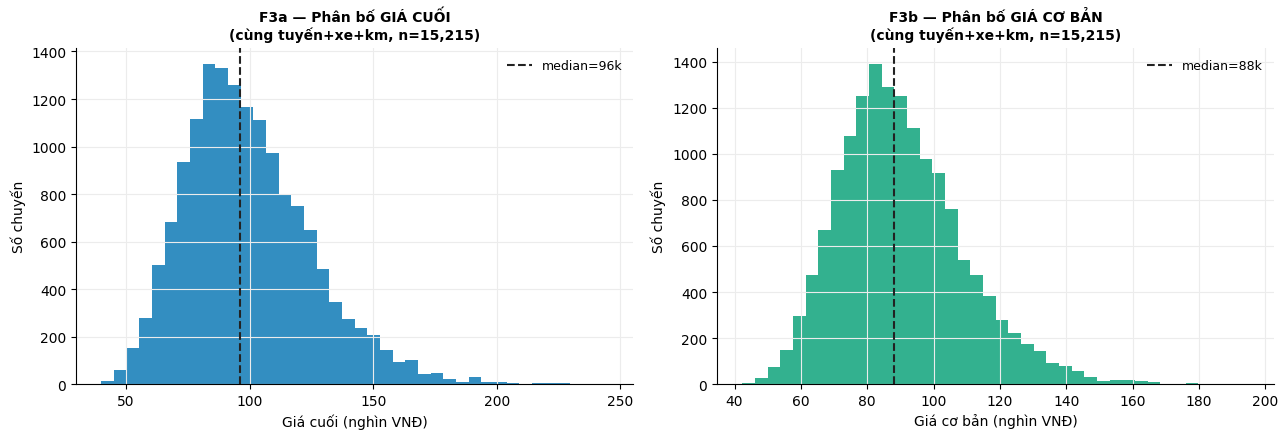

CV gia cuoi   : 25.9%
CV gia co ban : 20.9%


In [11]:
# ===== F3: phan bo cung dieu kien =====
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(band[PRICE]/1000, bins=40, color=BLUE, alpha=.8)
ax[0].axvline(band[PRICE].median()/1000, color="#222", ls="--",
              label=f"median={band[PRICE].median()/1000:.0f}k")
ax[0].set_xlabel("Giá cuối (nghìn VNĐ)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title(f"F3a — Phân bố GIÁ CUỐI\n(cùng tuyến+xe+km, n={len(band):,})",
                fontweight="bold", fontsize=10)
ax[0].legend(frameon=False, fontsize=9)

ax[1].hist(band.base_price/1000, bins=40, color=GREEN, alpha=.8)
ax[1].axvline(band.base_price.median()/1000, color="#222", ls="--",
              label=f"median={band.base_price.median()/1000:.0f}k")
ax[1].set_xlabel("Giá cơ bản (nghìn VNĐ)"); ax[1].set_ylabel("Số chuyến")
ax[1].set_title(f"F3b — Phân bố GIÁ CƠ BẢN\n(cùng tuyến+xe+km, n={len(band):,})",
                fontweight="bold", fontsize=10)
ax[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(OUT / "F3_phanbo_cungdieukien.png"); plt.show()

print(f"CV gia cuoi   : {band[PRICE].std()/band[PRICE].mean()*100:.1f}%")
print(f"CV gia co ban : {band.base_price.std()/band.base_price.mean()*100:.1f}%")

## Nhóm T — Khung giờ & tắc đường

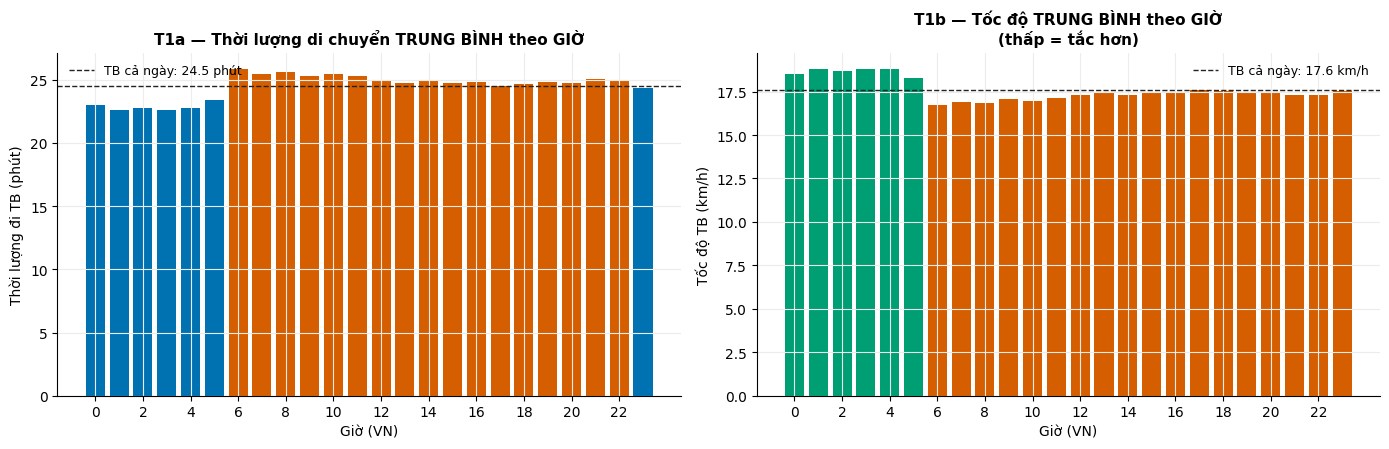

Gio TAC NHAT  : 6h (16.7 km/h, 25.8 phut)
Gio THONG NHAT: 1h (18.8 km/h, 22.6 phut)
Chenh lech toc do: 12.3%


In [12]:
# ===== T1: thoi luong & toc do theo 24 gio =====
h_dur = df.groupby("gio_vn").quote_duration.mean()/60
h_spd = df.groupby("gio_vn").speed_kmh.mean()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].bar(h_dur.index, h_dur.values,
          color=[RED if v > h_dur.mean() else BLUE for v in h_dur.values])
ax[0].axhline(h_dur.mean(), color="#222", ls="--", lw=1,
              label=f"TB cả ngày: {h_dur.mean():.1f} phút")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Thời lượng đi TB (phút)")
ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("T1a — Thời lượng di chuyển TRUNG BÌNH theo GIỜ", fontweight="bold", fontsize=11)

ax[1].bar(h_spd.index, h_spd.values,
          color=[RED if v < h_spd.mean() else GREEN for v in h_spd.values])
ax[1].axhline(h_spd.mean(), color="#222", ls="--", lw=1,
              label=f"TB cả ngày: {h_spd.mean():.1f} km/h")
ax[1].set_xlabel("Giờ (VN)"); ax[1].set_ylabel("Tốc độ TB (km/h)")
ax[1].set_xticks(range(0, 24, 2)); ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("T1b — Tốc độ TRUNG BÌNH theo GIỜ\n(thấp = tắc hơn)", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(OUT / "T1_thoiluong_tocdo_theo_gio.png"); plt.show()

print(f"Gio TAC NHAT  : {h_spd.idxmin()}h ({h_spd.min():.1f} km/h, {h_dur[h_spd.idxmin()]:.1f} phut)")
print(f"Gio THONG NHAT: {h_spd.idxmax()}h ({h_spd.max():.1f} km/h, {h_dur[h_spd.idxmax()]:.1f} phut)")
print(f"Chenh lech toc do: {(h_spd.max()/h_spd.min()-1)*100:.1f}%")

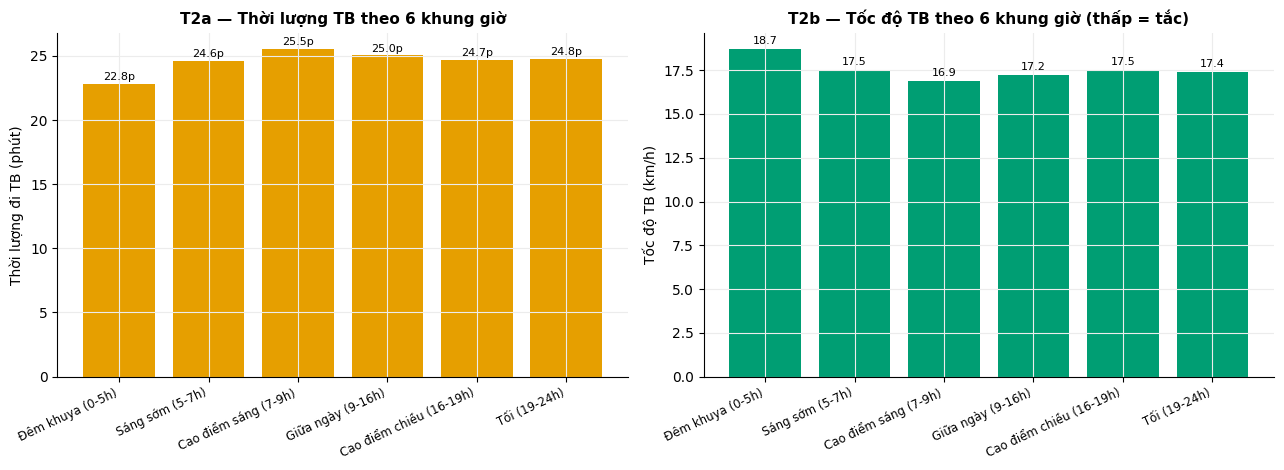

,so_chuyen,quang_duong_TB,thoi_luong_TB_phut,toc_do_TB_kmh,phut_per_km_TB
khung_gio,,,,,
0. Đêm khuya (0-5h),211248,6.55,22.79,18.70,3.60
1. Sáng sớm (5-7h),122628,6.55,24.63,17.50,3.87
2. Cao điểm sáng (7-9h),122629,6.54,25.53,16.89,4.01
3. Giữa ngày (9-16h),430841,6.56,25.04,17.24,3.93
4. Cao điểm chiều (16-19h),184488,6.57,24.67,17.52,3.86
5. Tối (19-24h),307589,6.56,24.77,17.39,3.89


In [13]:
# ===== T2: gop theo 6 khung gio sinh hoat =====
def khung_gio(h):
    if h < 5:  return "0. Đêm khuya (0-5h)"
    if h < 7:  return "1. Sáng sớm (5-7h)"
    if h < 9:  return "2. Cao điểm sáng (7-9h)"
    if h < 16: return "3. Giữa ngày (9-16h)"
    if h < 19: return "4. Cao điểm chiều (16-19h)"
    return "5. Tối (19-24h)"

df["khung_gio"] = df.gio_vn.apply(khung_gio)
g = df.groupby("khung_gio").agg(
    so_chuyen=(PRICE, "size"),
    quang_duong_TB=("quote_distance", "mean"),
    thoi_luong_TB_phut=("quote_duration", lambda s: s.mean()/60),
    toc_do_TB_kmh=("speed_kmh", "mean"),
    phut_per_km_TB=("dur_per_km", "mean")).round(2)

order = sorted(g.index)
ten = [o.split(". ")[1] for o in order]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
b1 = ax[0].bar(range(len(order)), g.loc[order, "thoi_luong_TB_phut"], color=ORANGE)
for i, v in enumerate(g.loc[order, "thoi_luong_TB_phut"]):
    ax[0].text(i, v+0.3, f"{v:.1f}p", ha="center", fontsize=8)
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(ten, rotation=25, ha="right", fontsize=8.5)
ax[0].set_ylabel("Thời lượng đi TB (phút)")
ax[0].set_title("T2a — Thời lượng TB theo 6 khung giờ", fontweight="bold", fontsize=11)

b2 = ax[1].bar(range(len(order)), g.loc[order, "toc_do_TB_kmh"], color=GREEN)
for i, v in enumerate(g.loc[order, "toc_do_TB_kmh"]):
    ax[1].text(i, v+0.3, f"{v:.1f}", ha="center", fontsize=8)
ax[1].set_xticks(range(len(order))); ax[1].set_xticklabels(ten, rotation=25, ha="right", fontsize=8.5)
ax[1].set_ylabel("Tốc độ TB (km/h)")
ax[1].set_title("T2b — Tốc độ TB theo 6 khung giờ (thấp = tắc)", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(OUT / "T2_6khunggio.png"); plt.show()

display(g.loc[order])

## Kiểm tra — đã sinh đủ 14 hình chưa

In [14]:
CAN_CO = [
    "O1_r2_giaithich.png", "O2_phanra_phuongsai.png",
    "B1_B2_distance_duration_vs_baseprice.png", "B3_B4_hour_weather_vs_baseprice.png",
    "B5_cv_khong_giam.png", "B6_permutation_baseprice.png",
    "M1_M2_imbalance_lastmult.png", "M3_M4_hour_weather_vs_multiplier.png",
    "M5_hang_so_thi_truong.png",
    "F1_amplitude_gia_cuoi.png", "F2_boston_vs_hcm.png", "F3_phanbo_cungdieukien.png",
    "T1_thoiluong_tocdo_theo_gio.png", "T2_6khunggio.png",
]
print(f"{'Hinh':<46} {'Trang thai':>12}")
print("-" * 60)
thieu = 0
for h in CAN_CO:
    p = OUT / h
    if p.exists():
        print(f"{h:<46} {p.stat().st_size/1024:>9.0f} KB")
    else:
        print(f"{h:<46} {'THIEU':>12}"); thieu += 1
print()
print(f"Da sinh {len(CAN_CO)-thieu}/{len(CAN_CO)} hinh")
assert thieu == 0, f"Thieu {thieu} hinh!"
print("=> DU 14 HINH. Bao cao bao_cao_tuan2_HOAN_CHINH.md gio tai tao duoc hoan toan.")

Hinh                                             Trang thai
------------------------------------------------------------
O1_r2_giaithich.png                                   31 KB
O2_phanra_phuongsai.png                               38 KB
B1_B2_distance_duration_vs_baseprice.png              77 KB
B3_B4_hour_weather_vs_baseprice.png                   56 KB
B5_cv_khong_giam.png                                  47 KB
B6_permutation_baseprice.png                          47 KB
M1_M2_imbalance_lastmult.png                          74 KB
M3_M4_hour_weather_vs_multiplier.png                  62 KB
M5_hang_so_thi_truong.png                             37 KB
F1_amplitude_gia_cuoi.png                             90 KB
F2_boston_vs_hcm.png                                  35 KB
F3_phanbo_cungdieukien.png                            58 KB
T1_thoiluong_tocdo_theo_gio.png                       60 KB
T2_6khunggio.png                                      75 KB

Da sinh 14/14 hinh
=> DU 14 HINH. Bao 

---

## Ghi chú

| Điểm | Nội dung |
|---|---|
| **Mẫu 20%** | `load(frac=0.2)` — đủ ổn định cho biểu đồ tổng hợp, chạy nhanh hơn nhiều |
| **`F2` dùng hằng số** | Các bội số 69,5× / 74,0× / 97,2× tính từ bộ Boston ở tuần 1, không đọc lại |
| **`B6` train model nhỏ** | HistGB 300 vòng trên tập `band` (~vài nghìn dòng), chỉ để đo importance |
| **Tiêu đề có dấu** | Bản trước sinh bởi script ngoài repo dùng tiếng Việt không dấu; bản này đã thêm dấu |

## Liên quan

| File | Vai trò |
|---|---|
| `docs/bao_cao_tuan2_HOAN_CHINH.md` | Báo cáo dùng 14 hình này |
| `model/evaluation/06_plot_uncertainty.ipynb` | Sinh `U1`–`U4` (cũng dùng trong báo cáo) |
| `analysis/00_DOC_TRUOC_TONG_HOP.md` | Bản đồ toàn bộ notebook phân tích |